In [130]:
# Do not change this cell
import numpy as np
import torch
from torch import nn
import matplotlib.pyplot as plt
from sklearn.datasets import make_blobs
from sklearn.model_selection import train_test_split

num_classes = 4
num_features = 2
random_seed = 1

# Create dataset
X, y = make_blobs(n_samples=10000, n_features=num_features, centers=num_classes, 
                  cluster_std=1.5, random_state=random_seed)

# Convert to tensor
X = torch.from_numpy(X).type(torch.float)
y = torch.from_numpy(y).type(torch.LongTensor)

# Split dataset into train/test sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=random_seed)

In [131]:
# TODO: you will design your model here
class SimpleModel(nn.Module):
    def __init__(self, input_size, output_size):
        # TODO: implement this method
        super().__init__()
        hidden_size = 20
        self.fc_1 = nn.Linear(input_size, hidden_size)
        self.fc_2 = nn.Linear(hidden_size, output_size)
        self.relu = nn.ReLU()        

    def forward(self, x):
        # TODO: implement this method
        h_relu = self.relu(self.fc_1(x))
        y_pred = self.fc_2(h_relu)
        return y_pred

In [132]:
def train_step(model, X_train, y_train, loss_fn, optimizer, device):
    # TODO: implement one epoch of training
    model.to(device)
    X_train, y_train = X_train.to(device), y_train.to(device)

    y_pred = model(X_train)
    loss = loss_fn(y_pred, y_train)

    correct = torch.eq(y_pred.argmax(dim = 1), y_train).sum().item() / len(y_train)

    optimizer.zero_grad()
    loss.backward()
    optimizer.step()

    return loss.item(), correct

In [133]:
def evaluation_step(model, X_test, y_test, loss_fn, device):
    # TODO: implement evaluation on test set
    model.eval()
    model.to(device)
    
    X_test, y_test = X_test.to(device), y_test.to(device)

    y_pred = model(X_test)
    loss = loss_fn(y_pred, y_test)

    accuracy = torch.eq(y_pred.argmax(dim = 1), y_test).sum().item() / len(y_test)

    return loss.item(), accuracy

In [134]:
def train_simple_model(X_train, y_train, X_test, y_test, random_seed):
    # Make device
    device = "cpu" 
    if torch.cuda.is_available(): 
        device = "cuda"
    else:
        if torch.backends.mps.is_available():
            device = "mps" 
    
    torch.manual_seed(random_seed) # do not change this

    # TODO: write codes to train your model here
    
    # model = SimpleModel(input_size=input_size, hidden_size=10, output_size=output_size).to(device)
    input_size = X_train.shape[1]
    output_size = 4
    model = SimpleModel(input_size, output_size).to(device)
    
    loss_fn = nn.CrossEntropyLoss()
    optimizer = torch.optim.SGD(model.parameters(), lr=0.1)
    
    num_epochs = 3001

    train_l = []
    train_acc = []
    test_l = []
    test_acc = []

    for epoch in range(num_epochs):
        
        trainl, trainacc = train_step(model, X_train, y_train, loss_fn, optimizer, device)
        
        testl, testacc = evaluation_step(model, X_test, y_test, loss_fn, device)

        train_l.append(trainl)
        train_acc.append(trainacc)

        test_l.append(testl)
        test_acc.append(testacc)

    return model, train_l, train_acc, test_l, test_acc
        

In [135]:
# TODO: plot accuracy curves
def plot_accuracy_performance(train_accuracies, test_accuracies):

    plt.figure(figsize = (8, 6))

    plt.plot(train_accuracies, label = 'Train accuracy')
    plt.plot(test_accuracies, label = 'Test accuracy')

    plt.xlabel('Epoch')
    plt.ylabel('Accuracy')
    plt.title('Training accuracy vs. Test accuracy')

    plt.legend()

In [136]:
# TODO: plot loss curves
def plot_loss_performance(train_losses, test_losses):

    plt.figure(figsize = (8, 6))

    plt.plot(train_losses, label = 'Train loss')
    plt.plot(test_losses, label = 'Test loss')

    plt.xlabel('Epoch')
    plt.ylabel('Loss')
    plt.title('Train loss vs. Test loss')

    plt.legend()

In [137]:
# TODO: plot decision boundary
def plot_decision_boundary(model, X_train, y_train):
    device = "mps" if torch.backends.mps.is_available() else "cpu"  
    
    min_xtrain = (X_train[:, 0].min() - 1).item() 
    max_xtrain = (X_train[:, 0].max() + 1).item()

    min_ytrain = (X_train[:, 1].min() - 1).item()
    max_ytrain = (X_train[:, 1].max() + 1).item()

    step = 0.01
    xx, yy = np.meshgrid(
        np.arange(min_xtrain, max_xtrain, step), 
        np.arange(min_ytrain, max_ytrain, step)
    )
    
    grid_data = np.c_[xx.ravel(), yy.ravel()]
    grid_data = torch.from_numpy(grid_data).type(torch.float).to(device)
    model.eval()

    with torch.inference_mode():
        y_logit = model(grid_data)
        y_predict = y_logit.argmax(dim = 1).cpu().numpy()

    preds = y_predict.reshape(xx.shape)

    plt.figure(figsize = (8, 6))
    
    plt.contourf(xx, yy, preds, alpha = 0.3)
    plt.contour(xx, yy, preds, linewidths = 0.7)
    
    plt.scatter(X_train[:, 0], X_train[:, 1], c = y_train)

    plt.title('Decision boundary with the training set')
    

In [138]:
# Do not change this cell
model, train_losses, train_accuracies, test_losses, test_accuracies\
    = train_simple_model(X_train, y_train, X_test, y_test, random_seed)

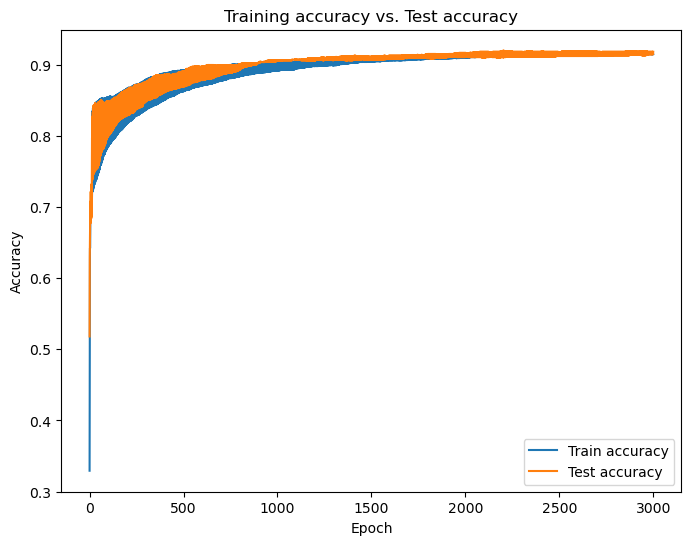

In [139]:
# Do not change this cell
plot_accuracy_performance(train_accuracies, test_accuracies)

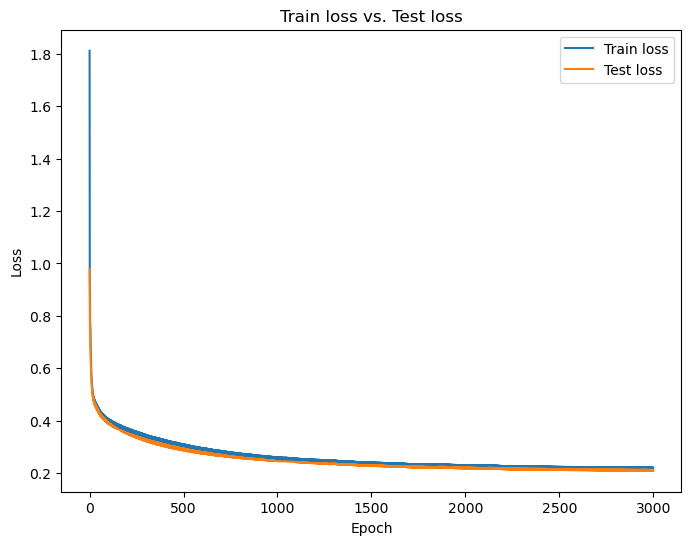

In [140]:
# Do not change this cell
plot_loss_performance(train_losses, test_losses)

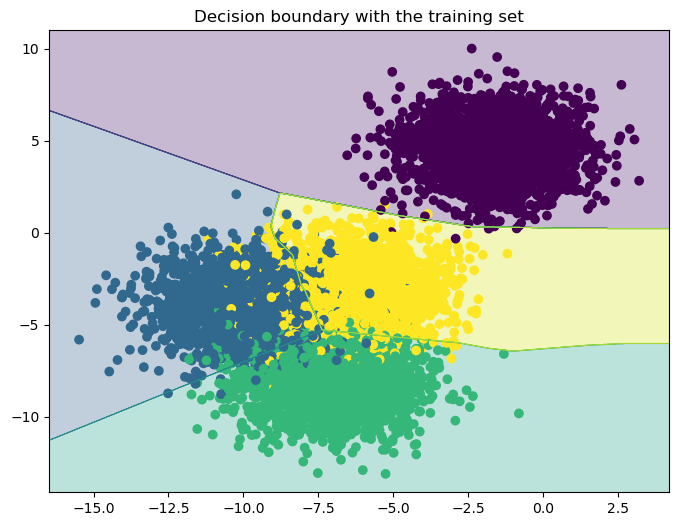

In [141]:
# Do not change this cell
plot_decision_boundary(model, X_train, y_train)